In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def show(img, title="", cmap="gray", size=(5,5)):
    plt.figure(figsize=size)
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.show()

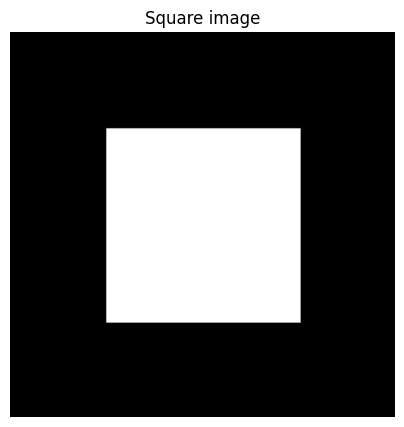

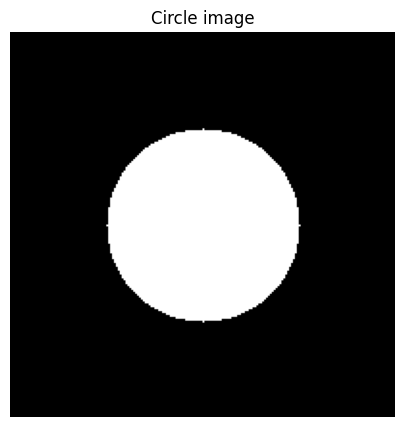

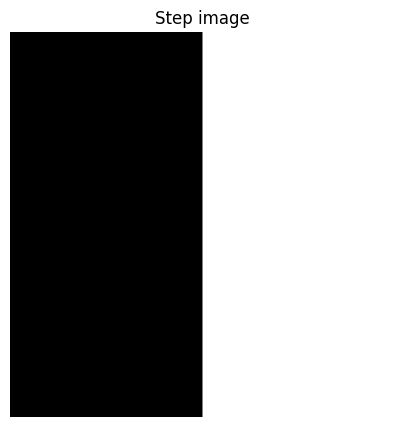

In [5]:
# Black background
img_square = np.zeros((200, 200), dtype=np.uint8)
img_circle = np.zeros((200, 200), dtype=np.uint8)
img_step = np.zeros((200, 200), dtype=np.uint8)

# Draw shapes
cv2.rectangle(img_square, (50, 50), (150, 150), 255, -1)
cv2.circle(img_circle, (100, 100), 50, 255, -1)

# Create a step image: left side dark, right side bright
img_step[:, :100] = 50
img_step[:, 100:] = 220

show(img_square, "Square image")
show(img_circle, "Circle image")
show(img_step, "Step image")

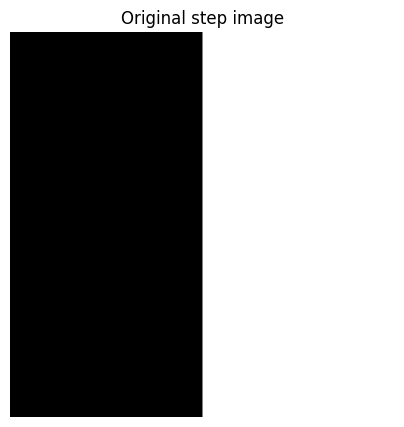

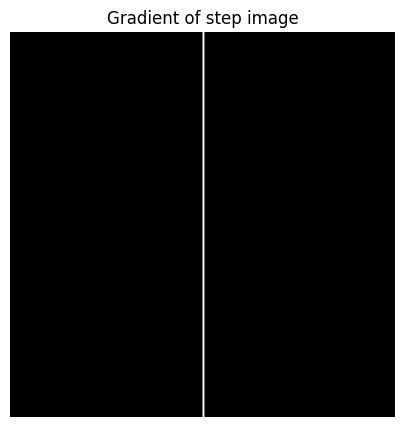

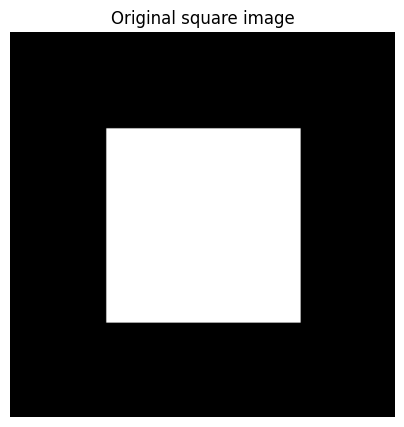

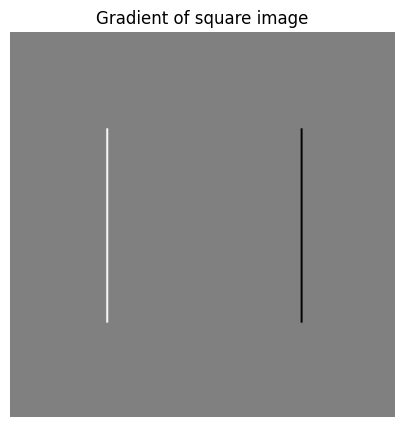

In [6]:
kernel_x = np.array([[-1, 1]], dtype=np.float32)

grad_step = cv2.filter2D(img_step, cv2.CV_64F, kernel_x)
grad_square = cv2.filter2D(img_square, cv2.CV_64F, kernel_x)

show(img_step, "Original step image")
show(grad_step, "Gradient of step image")
show(img_square, "Original square image")
show(grad_square, "Gradient of square image")

Changing the position of the squares.

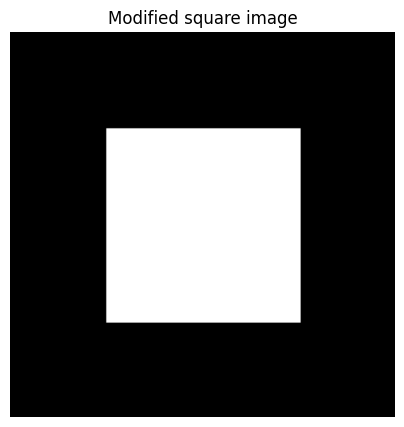

In [9]:
cv2.rectangle(img_square, (50, 50), (100, 150), 255, -1)
show(img_square, "Modified square image")

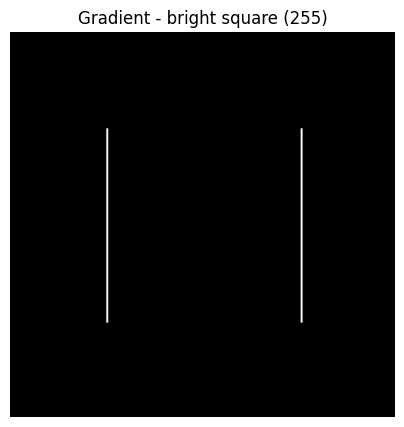

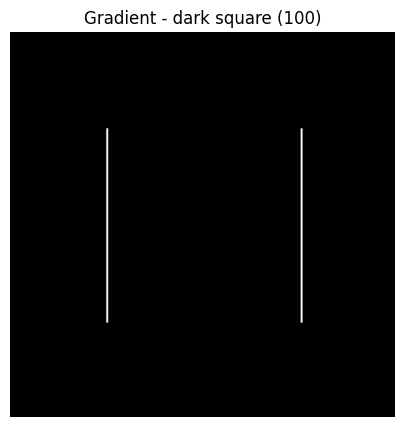

In [7]:
img_square_bright = np.zeros((200, 200), dtype=np.uint8)
img_square_dark = np.zeros((200, 200), dtype=np.uint8)

cv2.rectangle(img_square_bright, (50, 50), (150, 150), 255, -1)
cv2.rectangle(img_square_dark, (50, 50), (150, 150), 100, -1)

grad_bright = cv2.filter2D(img_square_bright, cv2.CV_64F, kernel_x)
grad_dark = cv2.filter2D(img_square_dark, cv2.CV_64F, kernel_x)

show(np.abs(grad_bright).astype(np.uint8), "Gradient - bright square (255)")
show(np.abs(grad_dark).astype(np.uint8), "Gradient - dark square (100)")

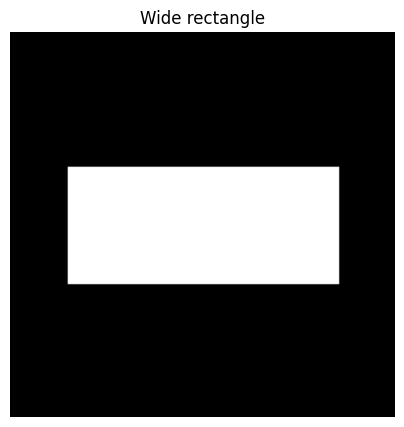

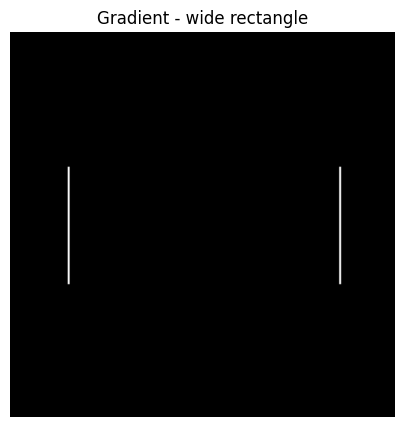

In [8]:
img_rect = np.zeros((200, 200), dtype=np.uint8)
cv2.rectangle(img_rect, (30, 70), (170, 130), 255, -1)

grad_rect = cv2.filter2D(img_rect, cv2.CV_64F, kernel_x)

show(img_rect, "Wide rectangle")
show(np.abs(grad_rect).astype(np.uint8), "Gradient - wide rectangle")

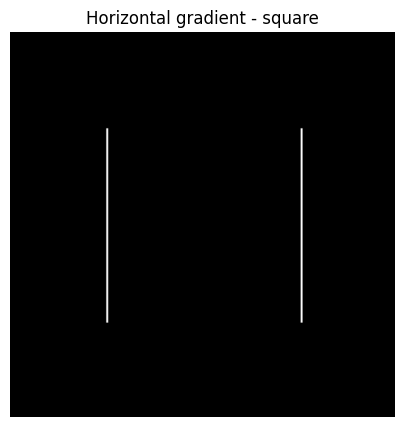

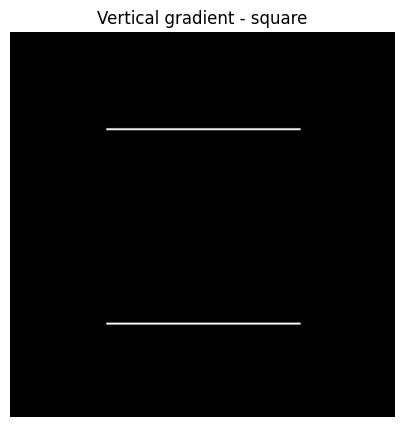

In [10]:
kernel_y = np.array([[-1], [1]], dtype=np.float32)

grad_square_x = cv2.filter2D(img_square, cv2.CV_64F, kernel_x)
grad_square_y = cv2.filter2D(img_square, cv2.CV_64F, kernel_y)

show(np.abs(grad_square_x).astype(np.uint8), "Horizontal gradient - square")
show(np.abs(grad_square_y).astype(np.uint8), "Vertical gradient - square")

In [ ]:
grad_circle_x = cv2.filter2D(img_circle, cv2.CV_64F, kernel_x)
grad_circle_y = cv2.filter2D(img_circle, cv2.CV_64F, kernel_y)

show(np.abs(grad_circle_x).astype(np.uint8), "Horizontal gradient - circle")
show(np.abs(grad_circle_y).astype(np.uint8), "Vertical gradient - circle")

In [ ]:
rng = np.random.default_rng(42)
noise = rng.normal(0, 25, img_square.shape)
img_square_noisy = np.clip(img_square.astype(np.float32) + noise, 0, 255).astype(np.uint8)

grad_noisy_x = cv2.filter2D(img_square_noisy, cv2.CV_64F, kernel_x)
grad_noisy_y = cv2.filter2D(img_square_noisy, cv2.CV_64F, kernel_y)

show(img_square_noisy, "Noisy square")
show(np.abs(grad_noisy_x).astype(np.uint8), "Gradient X - noisy square")
show(np.abs(grad_noisy_y).astype(np.uint8), "Gradient Y - noisy square")

In [ ]:
def simple_gradient(image, direction='x'):
    kx = np.array([[-1, 1]], dtype=np.float32)
    ky = np.array([[-1], [1]], dtype=np.float32)
    if direction == 'x':
        return cv2.filter2D(image, cv2.CV_64F, kx)
    else:
        return cv2.filter2D(image, cv2.CV_64F, ky)

gx = simple_gradient(img_square, 'x')
gy = simple_gradient(img_square, 'y')

show(np.abs(gx).astype(np.uint8), "simple_gradient x - square")
show(np.abs(gy).astype(np.uint8), "simple_gradient y - square")

In [ ]:
gx = simple_gradient(img_square, 'x')
gy = simple_gradient(img_square, 'y')

magnitude = np.sqrt(gx**2 + gy**2)
magnitude = np.clip(magnitude, 0, 255).astype(np.uint8)

show(np.abs(gx).astype(np.uint8), "Gradient X")
show(np.abs(gy).astype(np.uint8), "Gradient Y")
show(magnitude, "Gradient magnitude")

## Topic 2 — Sobel edge detector

In [ ]:
sobel_x = cv2.Sobel(img_square, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(img_square, cv2.CV_64F, 0, 1, ksize=3)

show(np.abs(sobel_x), "Sobel X - square")
show(np.abs(sobel_y), "Sobel Y - square")

In [ ]:
sobel_mag = np.sqrt(sobel_x**2 + sobel_y**2)
sobel_mag = np.clip(sobel_mag, 0, 255).astype(np.uint8)

show(img_square, "Original square")
show(sobel_mag, "Sobel magnitude - square")

In [ ]:
for k in [1, 3, 5]:
    sobel_k = cv2.Sobel(img_circle, cv2.CV_64F, 1, 0, ksize=k)
    show(np.abs(sobel_k), f"Sobel X on circle - ksize={k}")

In [ ]:
sobel_cx = cv2.Sobel(img_circle, cv2.CV_64F, 1, 0, ksize=3)
sobel_cy = cv2.Sobel(img_circle, cv2.CV_64F, 0, 1, ksize=3)

show(np.abs(sobel_cx), "Sobel X - circle")
show(np.abs(sobel_cy), "Sobel Y - circle")

In [ ]:
sobel_sq_x = cv2.Sobel(img_square, cv2.CV_64F, 1, 0, ksize=3)
sobel_sq_y = cv2.Sobel(img_square, cv2.CV_64F, 0, 1, ksize=3)
sobel_sq_mag = np.sqrt(sobel_sq_x**2 + sobel_sq_y**2)

sobel_ci_x = cv2.Sobel(img_circle, cv2.CV_64F, 1, 0, ksize=3)
sobel_ci_y = cv2.Sobel(img_circle, cv2.CV_64F, 0, 1, ksize=3)
sobel_ci_mag = np.sqrt(sobel_ci_x**2 + sobel_ci_y**2)

show(np.clip(sobel_sq_mag, 0, 255).astype(np.uint8), "Sobel magnitude - square")
show(np.clip(sobel_ci_mag, 0, 255).astype(np.uint8), "Sobel magnitude - circle")

In [ ]:
for k in [1, 3, 5]:
    sx = cv2.Sobel(img_square, cv2.CV_64F, 1, 0, ksize=k)
    sy = cv2.Sobel(img_square, cv2.CV_64F, 0, 1, ksize=k)
    mag = np.clip(np.sqrt(sx**2 + sy**2), 0, 255).astype(np.uint8)
    show(mag, f"Sobel magnitude - ksize={k}")

In [ ]:
sobel_step_x = cv2.Sobel(img_step, cv2.CV_64F, 1, 0, ksize=3)
sobel_step_y = cv2.Sobel(img_step, cv2.CV_64F, 0, 1, ksize=3)
sobel_step_mag = np.clip(np.sqrt(sobel_step_x**2 + sobel_step_y**2), 0, 255).astype(np.uint8)

show(img_step, "Step image")
show(sobel_step_mag, "Sobel magnitude - step image")

In [ ]:
img_sq_noisy = np.clip(img_square.astype(np.float32) + rng.normal(0, 25, img_square.shape), 0, 255).astype(np.uint8)

grad_n_x = cv2.filter2D(img_sq_noisy, cv2.CV_64F, kernel_x)
grad_n_y = cv2.filter2D(img_sq_noisy, cv2.CV_64F, kernel_y)
simple_mag = np.clip(np.sqrt(grad_n_x**2 + grad_n_y**2), 0, 255).astype(np.uint8)

sx_n = cv2.Sobel(img_sq_noisy, cv2.CV_64F, 1, 0, ksize=3)
sy_n = cv2.Sobel(img_sq_noisy, cv2.CV_64F, 0, 1, ksize=3)
sobel_mag_n = np.clip(np.sqrt(sx_n**2 + sy_n**2), 0, 255).astype(np.uint8)

show(img_sq_noisy, "Noisy square")
show(simple_mag, "Simple gradient magnitude - noisy")
show(sobel_mag_n, "Sobel magnitude - noisy")

In [ ]:
def sobel_edges(image, ksize=3):
    gx = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=ksize)
    gy = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=ksize)
    mag = np.sqrt(gx**2 + gy**2)
    return gx, gy, mag

gx, gy, mag = sobel_edges(img_square)
show(np.clip(mag, 0, 255).astype(np.uint8), "sobel_edges - square")

gx, gy, mag = sobel_edges(img_circle)
show(np.clip(mag, 0, 255).astype(np.uint8), "sobel_edges - circle")

gx, gy, mag = sobel_edges(img_step)
show(np.clip(mag, 0, 255).astype(np.uint8), "sobel_edges - step")

In [ ]:
_, _, mag_sobel = sobel_edges(img_square)
mag_sobel_u8 = np.clip(mag_sobel, 0, 255).astype(np.uint8)

for thresh in [50, 80, 120, 160]:
    binary = (mag_sobel_u8 > thresh).astype(np.uint8) * 255
    show(binary, f"Sobel threshold={thresh}")

## Topic 3 — Laplacian edge detector

In [ ]:
lap_square = cv2.Laplacian(img_square, cv2.CV_64F)
lap_circle = cv2.Laplacian(img_circle, cv2.CV_64F)

show(np.abs(lap_square), "Laplacian - square")
show(np.abs(lap_circle), "Laplacian - circle")

In [ ]:
img_sq_noisy2 = np.clip(img_square.astype(np.float32) + rng.normal(0, 25, img_square.shape), 0, 255).astype(np.uint8)

lap_no_blur = cv2.Laplacian(img_sq_noisy2, cv2.CV_64F)

img_sq_blur = cv2.GaussianBlur(img_sq_noisy2, (5, 5), 0)
lap_blur = cv2.Laplacian(img_sq_blur, cv2.CV_64F)

show(img_sq_noisy2, "Noisy square")
show(np.abs(lap_no_blur), "Laplacian without blur")
show(np.abs(lap_blur), "Laplacian after Gaussian blur")

In [ ]:
lap_step = cv2.Laplacian(img_step, cv2.CV_64F)
show(img_step, "Step image")
show(np.abs(lap_step), "Laplacian - step image")

In [ ]:
_, _, sobel_mag_step = sobel_edges(img_step)
lap_step2 = cv2.Laplacian(img_step, cv2.CV_64F)

show(np.clip(sobel_mag_step, 0, 255).astype(np.uint8), "Sobel magnitude - step")
show(np.abs(lap_step2), "Laplacian - step")

In [ ]:
for ksize in [1, 3]:
    lap = cv2.Laplacian(img_square, cv2.CV_64F, ksize=ksize)
    show(np.abs(lap), f"Laplacian ksize={ksize} - square")

In [ ]:
for sigma in [5, 15, 30]:
    noisy_img = np.clip(img_square.astype(np.float32) + rng.normal(0, sigma, img_square.shape), 0, 255).astype(np.uint8)
    lap = cv2.Laplacian(noisy_img, cv2.CV_64F)
    show(np.abs(lap), f"Laplacian - noise sigma={sigma}")

In [ ]:
img_noisy_for_blur = np.clip(img_square.astype(np.float32) + rng.normal(0, 25, img_square.shape), 0, 255).astype(np.uint8)

for ksize in [(3, 3), (5, 5), (7, 7)]:
    blurred = cv2.GaussianBlur(img_noisy_for_blur, ksize, 0)
    lap = cv2.Laplacian(blurred, cv2.CV_64F)
    show(np.abs(lap), f"Laplacian after blur {ksize}")

In [ ]:
img_noisy_count = np.clip(img_square.astype(np.float32) + rng.normal(0, 25, img_square.shape), 0, 255).astype(np.uint8)

lap_raw = cv2.Laplacian(img_noisy_count, cv2.CV_64F)
lap_raw_abs = np.abs(lap_raw).astype(np.uint8)

img_blurred_count = cv2.GaussianBlur(img_noisy_count, (5, 5), 0)
lap_blurred = cv2.Laplacian(img_blurred_count, cv2.CV_64F)
lap_blurred_abs = np.abs(lap_blurred).astype(np.uint8)

threshold = 10
nonzero_raw = np.count_nonzero(lap_raw_abs > threshold)
nonzero_blurred = np.count_nonzero(lap_blurred_abs > threshold)

print(f"Non-zero edge pixels without blur: {nonzero_raw}")
print(f"Non-zero edge pixels after blur:   {nonzero_blurred}")

In [ ]:
img_log = np.clip(img_square.astype(np.float32) + rng.normal(0, 15, img_square.shape), 0, 255).astype(np.uint8)

lap_direct = cv2.Laplacian(img_log, cv2.CV_64F)

img_log_blurred = cv2.GaussianBlur(img_log, (5, 5), 0)
lap_log = cv2.Laplacian(img_log_blurred, cv2.CV_64F)

show(np.abs(lap_direct), "Direct Laplacian")
show(np.abs(lap_log), "Laplacian of Gaussian (LoG)")

## Topic 4 — Canny edge detector

In [ ]:
edges1 = cv2.Canny(img_square, 50, 150)
edges2 = cv2.Canny(img_circle, 50, 150)

show(img_square, "Original square")
show(edges1, "Canny - square")
show(img_circle, "Original circle")
show(edges2, "Canny - circle")

In [ ]:
pairs = [(30, 90), (50, 150), (100, 200), (150, 250)]

for low, high in pairs:
    edges = cv2.Canny(img_circle, low, high)
    show(edges, f"Canny on circle - low={low}, high={high}")

In [ ]:
img_circle_noisy = np.clip(img_circle.astype(np.float32) + rng.normal(0, 30, img_circle.shape), 0, 255).astype(np.uint8)

canny_noisy = cv2.Canny(img_circle_noisy, 50, 150)
canny_blurred = cv2.Canny(cv2.GaussianBlur(img_circle_noisy, (5, 5), 0), 50, 150)

show(img_circle_noisy, "Noisy circle")
show(canny_noisy, "Canny on noisy circle")
show(canny_blurred, "Canny after blur")

In [ ]:
edges_step = cv2.Canny(img_step, 50, 150)
show(img_step, "Step image")
show(edges_step, "Canny - step image")

In [ ]:
for low, high in [(20, 60), (50, 150), (80, 200), (120, 250)]:
    e = cv2.Canny(img_step, low, high)
    show(e, f"Canny step - low={low}, high={high}")

In [ ]:
img_noisy_cmp = np.clip(img_square.astype(np.float32) + rng.normal(0, 25, img_square.shape), 0, 255).astype(np.uint8)

_, _, sobel_cmp = sobel_edges(img_noisy_cmp)
sobel_cmp_u8 = np.clip(sobel_cmp, 0, 255).astype(np.uint8)

lap_cmp = np.abs(cv2.Laplacian(img_noisy_cmp, cv2.CV_64F)).astype(np.uint8)

canny_cmp = cv2.Canny(img_noisy_cmp, 50, 150)

show(img_noisy_cmp, "Noisy square")
show(sobel_cmp_u8, "Sobel magnitude")
show(lap_cmp, "Laplacian")
show(canny_cmp, "Canny")

In [ ]:
for ksize in [(3, 3), (5, 5), (7, 7)]:
    blurred = cv2.GaussianBlur(img_circle_noisy, ksize, 0)
    e = cv2.Canny(blurred, 50, 150)
    show(e, f"Canny after GaussianBlur{ksize}")

In [ ]:
img_clean = img_circle.copy()
img_noisy_exp = np.clip(img_circle.astype(np.float32) + rng.normal(0, 30, img_circle.shape), 0, 255).astype(np.uint8)
img_blurred_exp = cv2.GaussianBlur(img_circle, (9, 9), 0)

for label, img in [("clean", img_clean), ("noisy", img_noisy_exp), ("blurred", img_blurred_exp)]:
    e = cv2.Canny(img, 50, 150)
    show(img, f"Input - {label}")
    show(e, f"Canny - {label}")

In [ ]:
def run_canny(image, low, high, blur=False):
    if blur:
        image = cv2.GaussianBlur(image, (5, 5), 0)
    return cv2.Canny(image, low, high)

for low, high in [(30, 90), (50, 150), (100, 200)]:
    e = run_canny(img_circle, low, high, blur=False)
    show(e, f"run_canny circle low={low} high={high} blur=False")
    e = run_canny(img_circle_noisy, low, high, blur=True)
    show(e, f"run_canny noisy circle low={low} high={high} blur=True")

In [ ]:
low, high = 160, 200

e_square = cv2.Canny(img_square, low, high)
e_circle = cv2.Canny(img_circle, low, high)

show(e_square, f"Canny square - low={low}, high={high}")
show(e_circle, f"Canny circle - low={low}, high={high}")